In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Sales_Data.csv")

In [3]:
print(df.info())
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115746 entries, 0 to 115745
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Additional Order items  114722 non-null  object 
 1   Category Name           115746 non-null  object 
 2   Customer City           115746 non-null  object 
 3   Customer Country        115746 non-null  object 
 4   Customer Fname          115746 non-null  object 
 5   Customer Id             115746 non-null  int64  
 6   Customer Segment        115746 non-null  object 
 7   Customer State          115746 non-null  object 
 8   Customer Zipcode        115743 non-null  float64
 9   Market                  115746 non-null  object 
 10  Order Customer Id       115746 non-null  int64  
 11  Order Date              115746 non-null  object 
 12  Order Id                115746 non-null  int64  
 13  Order Region            115746 non-null  object 
 14  Order Item Total    

In [4]:
print(df.isnull().sum())

Additional Order items    1024
Category Name                0
Customer City                0
Customer Country             0
Customer Fname               0
Customer Id                  0
Customer Segment             0
Customer State               0
Customer Zipcode             3
Market                       0
Order Customer Id            0
Order Date                   0
Order Id                     0
Order Region                 0
Order Item Total             0
Order Quantity               0
Product Price                0
Profit Margin                0
Profit Per Order             0
Sales                        0
dtype: int64


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce', dayfirst=True)

In [6]:
df['Profit Margin'] = df['Profit Margin'].str.replace('%', '').astype(float)


EDA DISTRIBUTION    

SALES-DISTRIBUTION

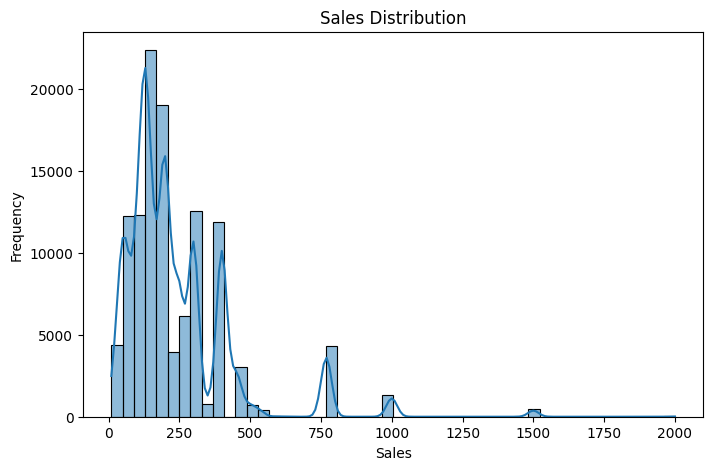

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

TOP 10 CATEGORIES BY TOTAL SALES

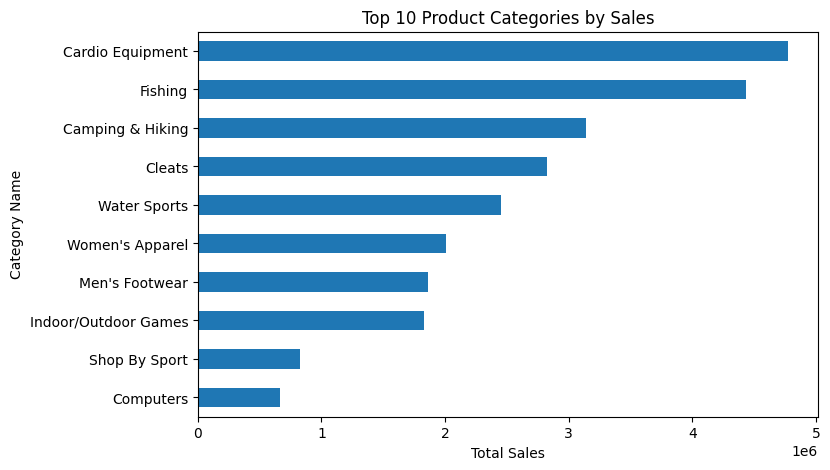

In [8]:
top_categories = df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_categories.plot(kind='barh', title="Top 10 Product Categories by Sales", figsize=(8,5))
plt.xlabel("Total Sales")
plt.gca().invert_yaxis()
plt.show()

PROFIT PER REGION

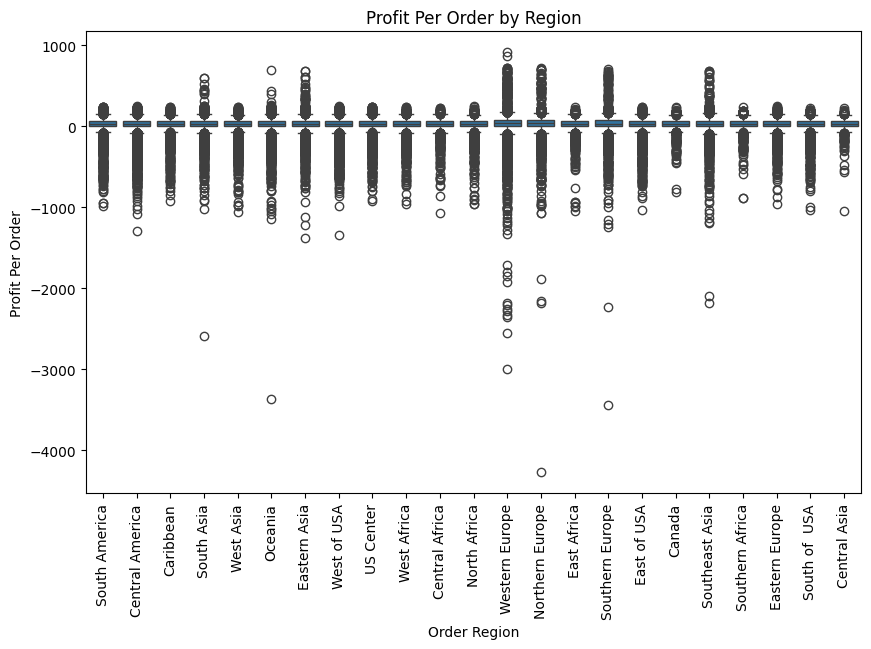

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Order Region', y='Profit Per Order')
plt.xticks(rotation=90)
plt.title("Profit Per Order by Region")
plt.show()

CORRELATION HEATMAP

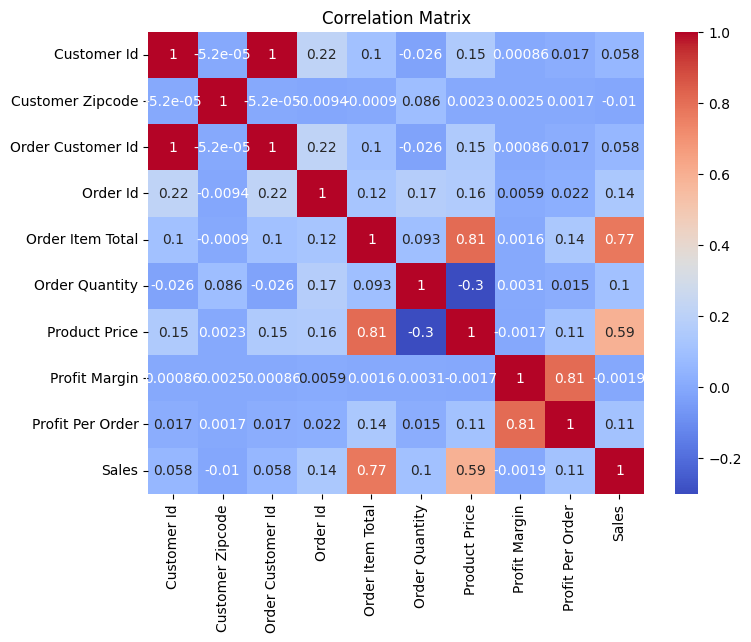

In [10]:
numeric_cols = df.select_dtypes(include='number')
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

PREDICTION CODE

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


PREPARE DATA FOR PREDICT

In [12]:
features = ['Product Price', 'Order Quantity', 'Profit Per Order']
df_model = df[features + ['Sales']].dropna()

X = df_model[features]
y = df_model['Sales']

Divide the data into train/test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train model using Linear Regression

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Predict the model

In [15]:
y_pred = model.predict(X_test)
#--evaluation--
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [16]:
print("🔍 Linear Regression Results:")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

🔍 Linear Regression Results:
Mean Absolute Error: 71.54
R² Score: 0.45


Actual vs Predicted Plot

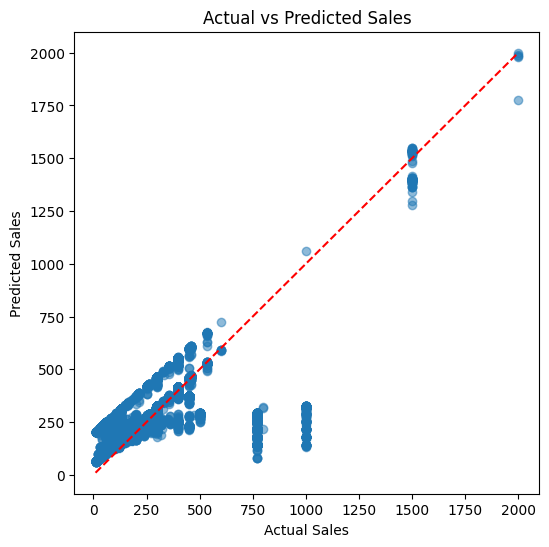

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.show()